In [142]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
# Carrega a planilha (sheet_name=1 equivale à segunda aba)
df = pd.read_excel("../Datos_Anonimo_20232_v2.xlsx", sheet_name=1)
df2 = pd.read_excel("../Datos_Anonimo_20231_v2.xlsx", sheet_name=1)

In [144]:
new_df = pd.concat([df, df2])


In [145]:
numerical_columns = new_df.select_dtypes(include=['int64', 'float64']).columns

In [146]:
correlation = new_df[numerical_columns].corr()

In [147]:
mask = np.triu(np.ones_like(correlation, dtype='bool'))

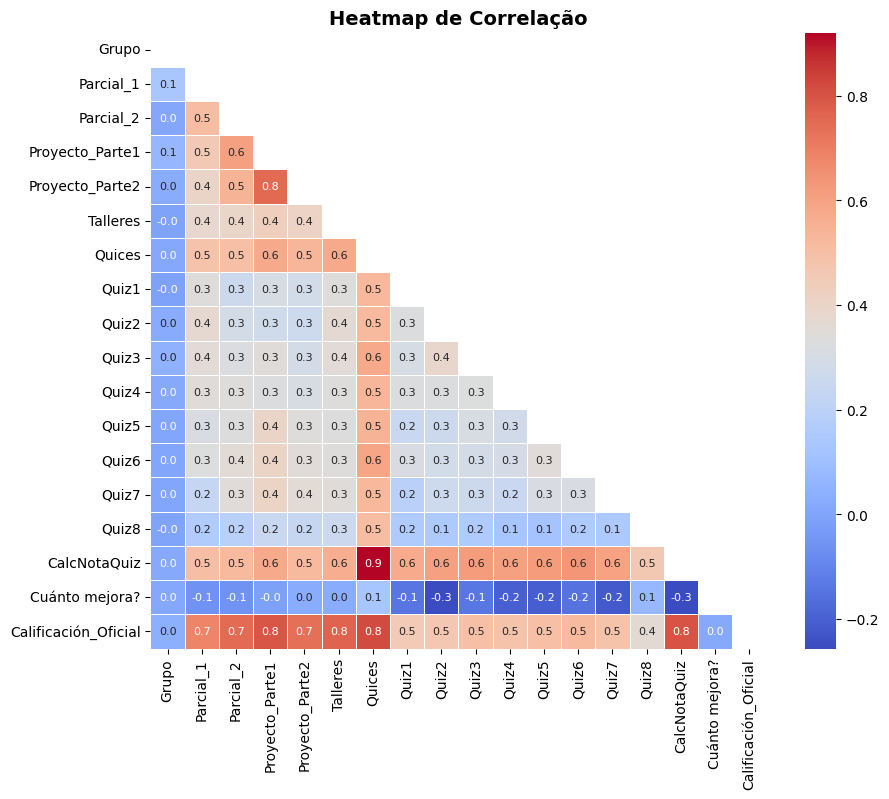

In [148]:
new_df = pd.concat([df, df2])
numerical_columns = new_df.select_dtypes(include=['int64', 'float64']).columns
correlation = new_df[numerical_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype='bool'))
fig, ax = plt.subplots(figsize=(10,8))

# Heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt='.1f',
    mask=mask,
    square=True,
    linewidths=.5,
    ax=ax,
    cmap='coolwarm',
    annot_kws={"size": 8}  
)

# Título
ax.set_title("Heatmap de Correlação", fontsize=14, fontweight="bold")

# Mostrar
plt.show()

In [149]:
from sklearn.preprocessing import OneHotEncoder

In [170]:
df_categorical = df.copy()
df_categorical2 = df2.copy()

In [171]:
df_categorical = df_categorical.dropna(subset=['STEM'])

In [172]:
cat_cols = ['Tipo_Documento', 'Edad', 'Genero', 'STEM', 'MejoraNotaQuices', 'Aprobo']

In [174]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Transforma a primeira tabela
encoded = encoder.fit_transform(df_categorical[cat_cols])

# Cria DataFrame com nomes corretos
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=df_categorical.index)

# Junta com o dataframe original (removendo as originais)
df_categorical = df_categorical.drop(columns=cat_cols).join(encoded_df)

In [173]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Transforma a segunda tabela
encoded2 = encoder.fit_transform(df_categorical2[cat_cols])

# Cria DataFrame com nomes corretos
encoded_df2 = pd.DataFrame(encoded2, columns=encoder.get_feature_names_out(cat_cols), index=df_categorical2.index)

# Junta com o dataframe original (removendo as originais)
df_categorical2 = df_categorical2.drop(columns=cat_cols).join(encoded_df2)

In [175]:
df_new_categorical = pd.concat([df_categorical, df_categorical2])

In [176]:
df_new_categorical = df_new_categorical.drop('STEM_NO', axis=1)
df_new_categorical = df_new_categorical.drop('MejoraNotaQuices_False', axis=1)
df_new_categorical = df_new_categorical.drop('Edad_Menor', axis=1)
df_new_categorical = df_new_categorical.drop('Aprobo_Reprobó', axis=1)


In [179]:
df_new_categorical.head()

,Periodo,Grupo,Horario,Nombre_Programa_Academico,Parcial_1,Parcial_2,Proyecto_Parte1,Proyecto_Parte2,Talleres,Quices,...,Tipo_Documento_CE,Tipo_Documento_PP,Tipo_Documento_TI,Edad_Mayor,Genero_femenino,Genero_femenino,Genero_masculino,STEM_SI,MejoraNotaQuices_True,Aprobo_Aprobó
0,2023-2,60,Jueves de 09:00AM a 12:00PM,PSICOLOGÍA,0.0,0.0,0.0,0.0,0.0,0.6,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2023-2,49,Jueves de 03:00PM a 06:00PM,ADMINISTRACIÓN DE NEGOCIOS,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2023-2,46,Miércoles de 12:00PM a 03:00PM,NEGOCIOS INTERNACIONALES,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2023-2,60,Jueves de 09:00AM a 12:00PM,DERECHO,0.0,0.0,4.0,5.0,2.5,2.3,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2023-2,53,Miércoles de 06:00PM a 09:00PM,ADMINISTRACIÓN DE NEGOCIOS,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


Analisando a correlação entre variáveis - Curso da área e quantidade de aprovados

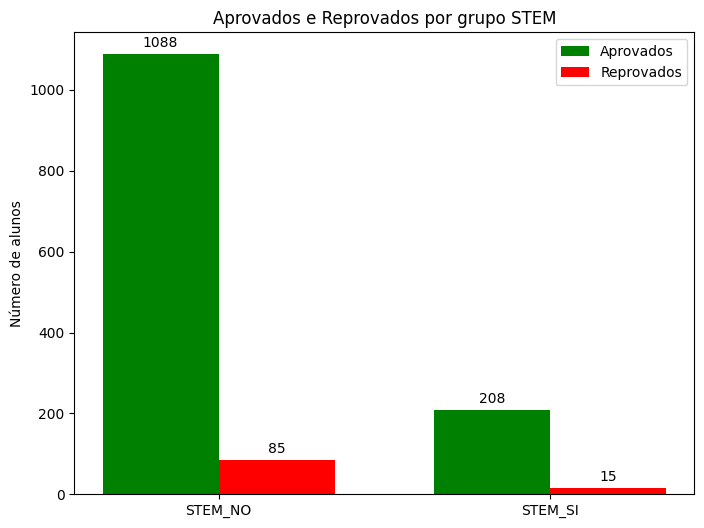

In [177]:
sumario = df_new_categorical.groupby('STEM_SI')['Aprobo_Aprobó'].value_counts().unstack(fill_value=0)

labels = ['STEM_NO', 'STEM_SI']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por grupo STEM')
ax.legend()

plt.show()


Gênero e taxa de aprovados

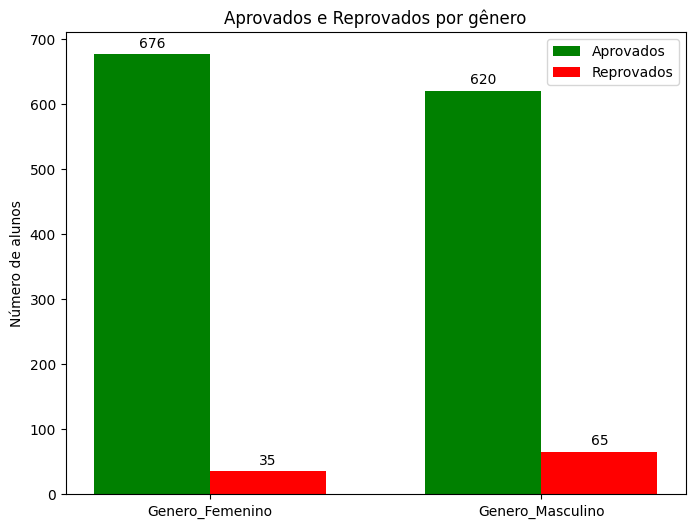

In [178]:
sumario = df_new_categorical.groupby('Genero_masculino')['Aprobo_Aprobó'].value_counts().unstack(fill_value=0)

labels = ['Genero_Femenino', 'Genero_Masculino']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por gênero')
ax.legend()

plt.show()

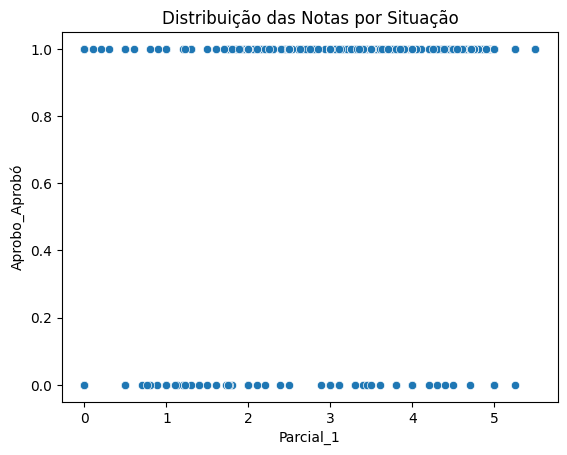

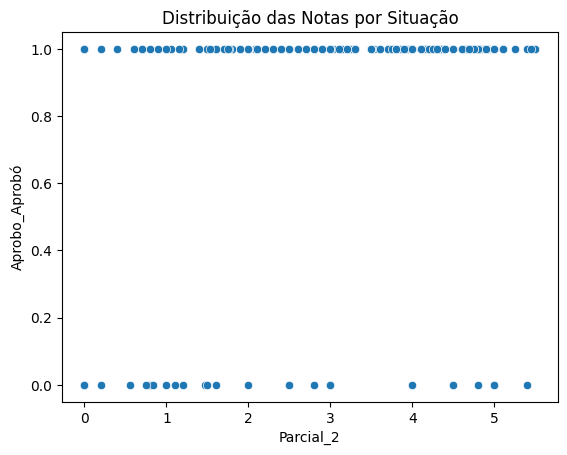

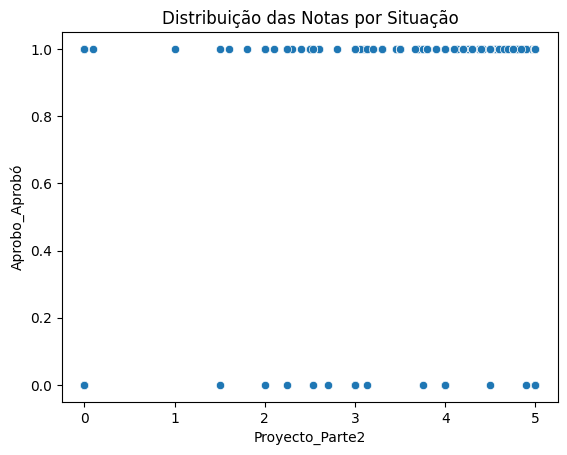

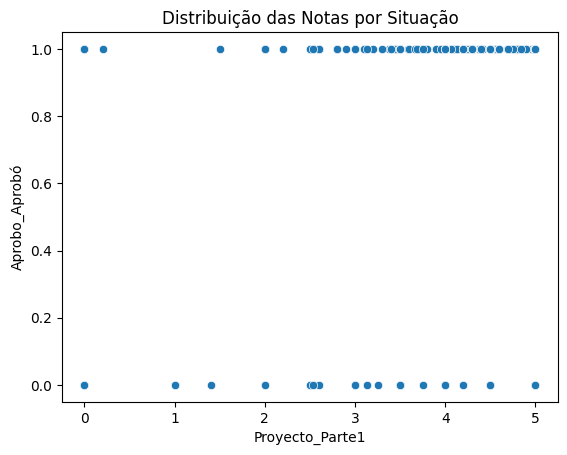

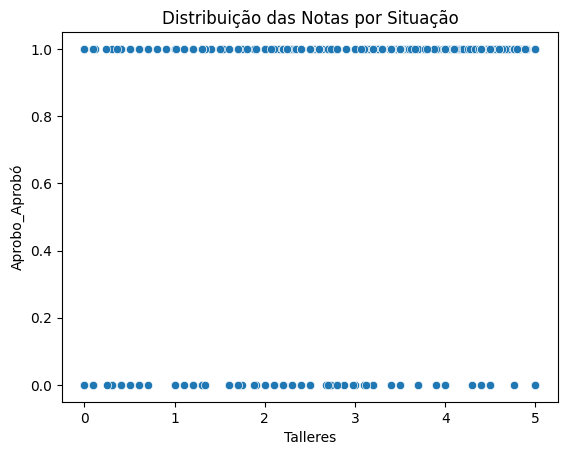

In [190]:
notas = ['Parcial_1','Parcial_2','Proyecto_Parte2','Proyecto_Parte1','Talleres']

for n in notas:
    sns.scatterplot(x=df_new_categorical[n], y='Aprobo_Aprobó', data=df_new_categorical)
    plt.title('Distribuição das Notas por Situação')
    plt.show()